## 🔍 Feature Extraction, Scaling, and Selection

### 1. Feature Extraction
- Creating new features from raw data to better represent the problem.
- Helps reduce dimensionality and capture important information.
- Examples:
  - **PCA (Principal Component Analysis)** — transforms features into uncorrelated components.
  - **Text Vectorization** — converting text to numeric vectors (e.g., TF-IDF).
  - **Image feature extraction** — edges, shapes, colors.

---

### 2. Feature Scaling
- Standardizes the range of features for better model performance.
- Important for distance-based algorithms (e.g., KNN, SVM, Gradient Descent).
- Common methods:
  - **Normalization (Min-Max Scaling):** scales data to [0,1].
   
    \[
    X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}
    \]
  - **Standardization (Z-score Scaling):** scales data to mean=0, std=1.
    \[
    X_{std} = \frac{X - \mu}{\sigma}
    \]

---

### 3. Feature Selection
- Selecting the most relevant features to improve model accuracy and reduce overfitting.
- Types:
  - **Filter methods:** Use statistical tests (e.g., correlation, chi-square) to select features.
  - **Wrapper methods:** Use model performance to evaluate subsets of features (e.g., Recursive Feature Elimination).
  - **Embedded methods:** Perform feature selection during model training (e.g., Lasso regression).
- Benefits:
  - Reduces training time
  - Improves model interpretability
  - Mitigates curse of dimensionality

---


## Min-Max Scaling

In [2]:
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Load the taxis dataset
df = sns.load_dataset('taxis')

# Select features to scale
features = ['distance', 'fare', 'tip']

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the selected features (learn min and max)
scaler.fit(df[features])

# Access learned min, max, and range values
print("Feature-wise minimum values learned (data_min_):")
print(scaler.data_min_)

print("\nFeature-wise maximum values learned (data_max_):")
print(scaler.data_max_)

print("\nFeature-wise data range (max - min):")
print(scaler.data_range_)

# Transform the data (scale features between 0 and 1)
scaled_features = scaler.transform(df[features])

# Show original and scaled values for first 5 rows
print("\nOriginal values (first 5 rows):")
print(df[features].head())

print("\nScaled values (first 5 rows):")
print(scaled_features[:5])

# Manual calculation for first row to verify
original_values = df[features].iloc[0].values
manual_scaled = (original_values - scaler.data_min_) / scaler.data_range_

print("\nOriginal first row values:", original_values)
print("Manual scaled values (calculated):", manual_scaled)
print("Scaler's scaled values (transform):", scaled_features[0])



Feature-wise minimum values learned (data_min_):
[0. 1. 0.]

Feature-wise maximum values learned (data_max_):
[ 36.7 150.   33.2]

Feature-wise data range (max - min):
[ 36.7 149.   33.2]

Original values (first 5 rows):
   distance  fare   tip
0      1.60   7.0  2.15
1      0.79   5.0  0.00
2      1.37   7.5  2.36
3      7.70  27.0  6.15
4      2.16   9.0  1.10

Scaled values (first 5 rows):
[[0.04359673 0.04026846 0.06475904]
 [0.02152589 0.02684564 0.        ]
 [0.0373297  0.04362416 0.07108434]
 [0.20980926 0.17449664 0.18524096]
 [0.05885559 0.05369128 0.03313253]]

Original first row values: [1.6  7.   2.15]
Manual scaled values (calculated): [0.04359673 0.04026846 0.06475904]
Scaler's scaled values (transform): [0.04359673 0.04026846 0.06475904]


## Standarisation

Feature-wise mean (mean_):
[19.78594262  2.99827869  2.56967213]

Feature-wise std deviation (scale_):
[8.88415058 1.38079995 0.94914883]

Original first 5 rows:
[[16.99  1.01  2.  ]
 [10.34  1.66  3.  ]
 [21.01  3.5   3.  ]
 [23.68  3.31  2.  ]
 [24.59  3.61  4.  ]]

Manual standardized (first 5 rows):
[[-0.31471131 -1.43994695 -0.60019263]
 [-1.06323531 -0.96920534  0.45338292]
 [ 0.1377799   0.36335554  0.45338292]
 [ 0.4383151   0.22575414 -0.60019263]
 [ 0.5407447   0.4430195   1.50695847]]

Scaler's standardized (first 5 rows):
[[-0.31471131 -1.43994695 -0.60019263]
 [-1.06323531 -0.96920534  0.45338292]
 [ 0.1377799   0.36335554  0.45338292]
 [ 0.4383151   0.22575414 -0.60019263]
 [ 0.5407447   0.4430195   1.50695847]]


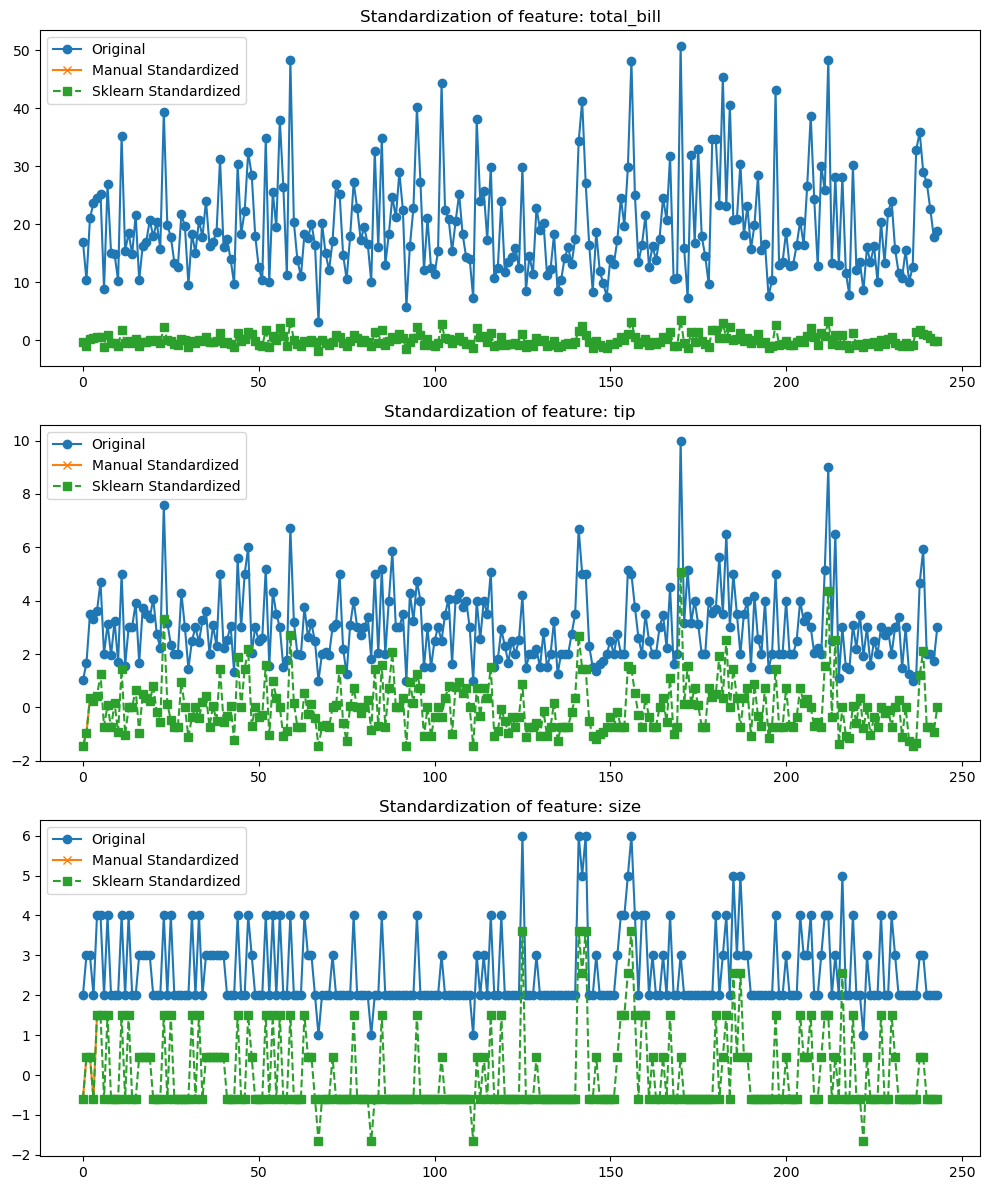

In [4]:
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load tips dataset
df = sns.load_dataset('tips')

# Features to standardize
features = ['total_bill', 'tip', 'size']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit scaler and transform data
scaler.fit(df[features])
scaled_features = scaler.transform(df[features])

# Access mean and std learned by scaler
print("Feature-wise mean (mean_):")
print(scaler.mean_)

print("\nFeature-wise std deviation (scale_):")
print(scaler.scale_)

# Manual standardization for the first 5 rows
original_values = df[features].head().values
manual_scaled = (original_values - scaler.mean_) / scaler.scale_

print("\nOriginal first 5 rows:")
print(original_values)

print("\nManual standardized (first 5 rows):")
print(manual_scaled)

print("\nScaler's standardized (first 5 rows):")
print(scaled_features[:5])

# Visualize original vs standardized (manual and sklearn)
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, feature in enumerate(features):
    axes[i].plot(df[feature], label='Original', marker='o')
    axes[i].plot(manual_scaled[:, i], label='Manual Standardized', marker='x')
    axes[i].plot(scaled_features[:, i], label='Sklearn Standardized', marker='s', linestyle='--')
    axes[i].set_title(f'Standardization of feature: {feature}')
    axes[i].legend()

plt.tight_layout()
plt.show()


## Unit scaling

In [5]:
import seaborn as sns
import numpy as np
from sklearn.preprocessing import Normalizer
import pandas as pd

# Load iris dataset
iris = sns.load_dataset('iris')

# Features only (exclude target)
X = iris.drop(columns='species')

# Initialize Normalizer (default norm='l2' for unit vector scaling)
normalizer = Normalizer()

# Apply normalization
X_normalized = normalizer.fit_transform(X)

# Convert back to DataFrame for easier viewing
df_normalized = pd.DataFrame(X_normalized, columns=X.columns)

# Show first 5 rows
print("Original data (first 5 rows):")
print(X.head())

print("\nNormalized data (unit vector scaling) first 5 rows:")
print(df_normalized.head())

# Check the norm of first 5 rows (should be 1)
norms = np.linalg.norm(X_normalized, axis=1)
print("\nNorms of normalized rows (should be 1):")
print(norms[:5])


Original data (first 5 rows):
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Normalized data (unit vector scaling) first 5 rows:
   sepal_length  sepal_width  petal_length  petal_width
0      0.803773     0.551609      0.220644     0.031521
1      0.828133     0.507020      0.236609     0.033801
2      0.805333     0.548312      0.222752     0.034269
3      0.800030     0.539151      0.260879     0.034784
4      0.790965     0.569495      0.221470     0.031639

Norms of normalized rows (should be 1):
[1. 1. 1. 1. 1.]


## PCA

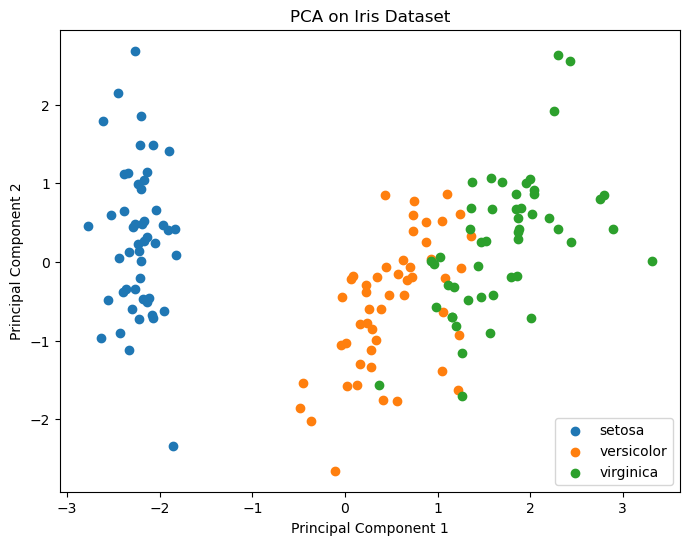

Explained variance ratio: [0.72962445 0.22850762]


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset
iris = sns.load_dataset('iris')
X = iris.drop(columns='species')
y = iris['species']

# Standardize data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot results
plt.figure(figsize=(8,6))
for species in y.unique():
    plt.scatter(
        X_pca[y == species, 0], 
        X_pca[y == species, 1], 
        label=species
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on Iris Dataset')
plt.legend()
plt.show()

# Explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)
